In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../data/raw/mtsamples.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4999 entries, 0 to 4998
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Unnamed: 0         4999 non-null   int64 
 1   description        4999 non-null   object
 2   medical_specialty  4999 non-null   object
 3   sample_name        4999 non-null   object
 4   transcription      4966 non-null   object
 5   keywords           3931 non-null   object
dtypes: int64(1), object(5)
memory usage: 234.5+ KB


In [5]:
df.head()

,Unnamed: 0,description,medical_specialty,sample_name,transcription,keywords
0,0,A 23-year-old white female presents with comp...,Allergy / Immunology,Allergic Rhinitis,"SUBJECTIVE:, This 23-year-old white female pr...","allergy / immunology, allergic rhinitis, aller..."
1,1,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 2,"PAST MEDICAL HISTORY:, He has difficulty climb...","bariatrics, laparoscopic gastric bypass, weigh..."
2,2,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 1,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...","bariatrics, laparoscopic gastric bypass, heart..."
3,3,2-D M-Mode. Doppler.,Cardiovascular / Pulmonary,2-D Echocardiogram - 1,"2-D M-MODE: , ,1. Left atrial enlargement wit...","cardiovascular / pulmonary, 2-d m-mode, dopple..."
4,4,2-D Echocardiogram,Cardiovascular / Pulmonary,2-D Echocardiogram - 2,1. The left ventricular cavity size and wall ...,"cardiovascular / pulmonary, 2-d, doppler, echo..."


In [8]:
print(df.iloc[0,4])

SUBJECTIVE:,  This 23-year-old white female presents with complaint of allergies.  She used to have allergies when she lived in Seattle but she thinks they are worse here.  In the past, she has tried Claritin, and Zyrtec.  Both worked for short time but then seemed to lose effectiveness.  She has used Allegra also.  She used that last summer and she began using it again two weeks ago.  It does not appear to be working very well.  She has used over-the-counter sprays but no prescription nasal sprays.  She does have asthma but doest not require daily medication for this and does not think it is flaring up.,MEDICATIONS: , Her only medication currently is Ortho Tri-Cyclen and the Allegra.,ALLERGIES: , She has no known medicine allergies.,OBJECTIVE:,Vitals:  Weight was 130 pounds and blood pressure 124/78.,HEENT:  Her throat was mildly erythematous without exudate.  Nasal mucosa was erythematous and swollen.  Only clear drainage was seen.  TMs were clear.,Neck:  Supple without adenopathy.,L

In [9]:
print(f"Especialidades únicas: {df['medical_specialty'].nunique()}")
df['medical_specialty'].value_counts()

Especialidades únicas: 40


medical_specialty
Surgery                          1103
Consult - History and Phy.        516
Cardiovascular / Pulmonary        372
Orthopedic                        355
Radiology                         273
General Medicine                  259
Gastroenterology                  230
Neurology                         223
SOAP / Chart / Progress Notes     166
Obstetrics / Gynecology           160
Urology                           158
Discharge Summary                 108
ENT - Otolaryngology               98
Neurosurgery                       94
Hematology - Oncology              90
Ophthalmology                      83
Nephrology                         81
Emergency Room Reports             75
Pediatrics - Neonatal              70
Pain Management                    62
Psychiatry / Psychology            53
Office Notes                       51
Podiatry                           47
Dermatology                        29
Dentistry                          27
Cosmetic / Plastic Surgery      

In [10]:
df.isnull().sum()

Unnamed: 0              0
description             0
medical_specialty       0
sample_name             0
transcription          33
keywords             1068
dtype: int64

In [11]:
# Limpiamos nulos primero
df = df.dropna(subset=['transcription'])
print(f"Después de limpiar: {len(df)} muestras")

Después de limpiar: 4966 muestras


Decido por simplicidad reducir a 20 clases, las 19 primeras + Others.

In [13]:
# Ver Top 19
top_19_specialties = df['medical_specialty'].value_counts().head(19)
print("Top 19 especialidades:")
print(top_19_specialties)
print(f"\nTotal en Top 19: {top_19_specialties.sum()}")

# Resto en Others
others_count = len(df) - top_19_specialties.sum()
print(f"En 'Others': {others_count}")

Top 19 especialidades:
medical_specialty
Surgery                          1088
Consult - History and Phy.        516
Cardiovascular / Pulmonary        371
Orthopedic                        355
Radiology                         273
General Medicine                  259
Gastroenterology                  224
Neurology                         223
SOAP / Chart / Progress Notes     166
Urology                           156
Obstetrics / Gynecology           155
Discharge Summary                 108
ENT - Otolaryngology               96
Neurosurgery                       94
Hematology - Oncology              90
Ophthalmology                      83
Nephrology                         81
Emergency Room Reports             75
Pediatrics - Neonatal              70
Name: count, dtype: int64

Total en Top 19: 4483
En 'Others': 483


In [14]:
top_19_list = top_19_specialties.index.tolist()
df['medical_specialty'] = df['medical_specialty'].apply(lambda x: x if x in top_19_list else 'Others')

df['medical_specialty'].value_counts()

medical_specialty
 Surgery                          1088
 Consult - History and Phy.        516
Others                             483
 Cardiovascular / Pulmonary        371
 Orthopedic                        355
 Radiology                         273
 General Medicine                  259
 Gastroenterology                  224
 Neurology                         223
 SOAP / Chart / Progress Notes     166
 Urology                           156
 Obstetrics / Gynecology           155
 Discharge Summary                 108
 ENT - Otolaryngology               96
 Neurosurgery                       94
 Hematology - Oncology              90
 Ophthalmology                      83
 Nephrology                         81
 Emergency Room Reports             75
 Pediatrics - Neonatal              70
Name: count, dtype: int64

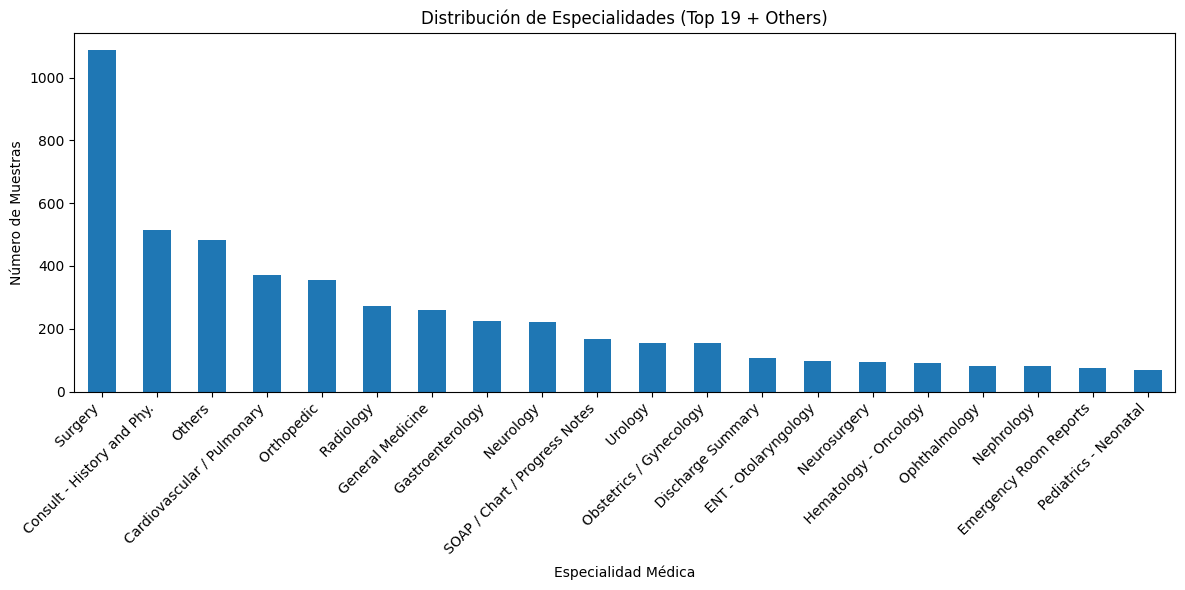

In [20]:
plt.figure(figsize=(12, 6))
df['medical_specialty'].value_counts().plot(kind='bar')
plt.xlabel('Especialidad Médica')
plt.ylabel('Número de Muestras')
plt.title('Distribución de Especialidades (Top 19 + Others)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Inspeccionamos tamaño de las transcripciones.

In [16]:
df['text_length'] = df['transcription'].str.len()

print(df['text_length'].describe())

count     4966.000000
mean      3052.314337
std       1994.082239
min         11.000000
25%       1608.000000
50%       2667.000000
75%       4011.000000
max      18425.000000
Name: text_length, dtype: float64


In [17]:
# Ver textos extremos
print("Textos muy cortos (< 100 caracteres):")
print(df[df['text_length'] < 100][['medical_specialty', 'transcription']].head())

print("\nTextos muy largos (> 10000 caracteres):")
print(df[df['text_length'] > 10000][['medical_specialty', 'text_length']].head())

Textos muy cortos (< 100 caracteres):
    medical_specialty                                      transcription
24            Urology                                  CHIEF COMPLAINT:,
166           Urology  The patient tolerated the procedure well and w...
318           Surgery  PREOPERATIVE DIAGNOSIS:  ,1.  Right carpal tun...
606           Surgery   PREOPERATIVE DIAGNOSIS:  ,Lateral epicondylitis.
640           Surgery  PREOPERATIVE DIAGNOSIS:,  Cholelithiasis; poss...

Textos muy largos (> 10000 caracteres):
    medical_specialty  text_length
149           Urology        12574
407           Surgery        10443
917           Surgery        10962
943           Surgery        12574
977           Surgery        11028


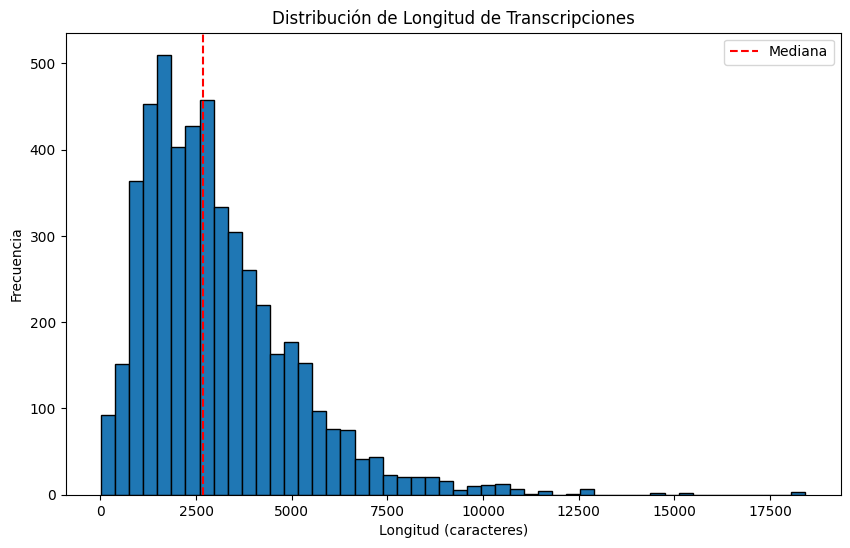

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(df['text_length'], bins=50, edgecolor='black')
plt.xlabel('Longitud (caracteres)')
plt.ylabel('Frecuencia')
plt.title('Distribución de Longitud de Transcripciones')
plt.axvline(df['text_length'].median(), color='red', linestyle='--', label='Mediana')
plt.legend()
plt.show()

Decido hacer chunks en las instancias grandes para poder procesarlo con Modelos pequeños como DistilBERT y BioBERT. De paso nos quedamos solo con las columnas relevantes, medical_speciality y Transcription

In [21]:
def create_chunks(text, chunk_size=2000, overlap=200):
    if len(text) <= chunk_size:
        return [text]
    chunks = []
    start = 0
    while start < len(text):
        end = min(start + chunk_size, len(text))
        chunks.append(text[start:end])
        start += chunk_size - overlap
    return chunks

In [22]:
sample_text = df[df['text_length'] > 2500].iloc[0]['transcription']
sample_chunks = create_chunks(sample_text)
print(f"Texto original: {len(sample_text)} caracteres")
print(f"Número de chunks: {len(sample_chunks)}")
print(f"Longitud de chunks: {[len(c) for c in sample_chunks]}")

Texto original: 4422 caracteres
Número de chunks: 3
Longitud de chunks: [2000, 2000, 822]


In [28]:
def process_dataframe_with_chunks(df, chunk_size=2000, overlap=200):
    processed_data = []
    for idx, row in df.iterrows():
        text = row['transcription']
        specialty = row['medical_specialty']
        
        # Crear chunks
        chunks = create_chunks(text, chunk_size, overlap)

        for chunk_idx, chunk in enumerate(chunks):
            processed_data.append({
                'original_id': idx,
                'chunk_id' : chunk_idx,
                'medical_specialty': specialty,
                'transcription': chunk,
                'total_chunks' : len(chunks)
            })
    return pd.DataFrame(processed_data)

# Procesar dataset con chunks
df_processed = process_dataframe_with_chunks(df)

print(f"\n✅ Dataset original: {len(df)} muestras")
print(f"✅ Dataset con chunks: {len(df_processed)} muestras")
print(f"✅ Incremento: {len(df_processed) - len(df)} muestras adicionales")

# Ver distribución de especialidades después del chunking
print("\n📊 Distribución final:")
print(df_processed['medical_specialty'].value_counts())


✅ Dataset original: 4966 muestras
✅ Dataset con chunks: 10606 muestras
✅ Incremento: 5640 muestras adicionales

📊 Distribución final:
medical_specialty
 Surgery                          2402
 Consult - History and Phy.       1286
Others                            1082
 Orthopedic                        887
 Cardiovascular / Pulmonary        764
 General Medicine                  554
 Neurology                         501
 Radiology                         402
 Gastroenterology                  385
 Obstetrics / Gynecology           330
 Urology                           303
 SOAP / Chart / Progress Notes     271
 Neurosurgery                      233
 Discharge Summary                 208
 ENT - Otolaryngology              194
 Emergency Room Reports            179
 Hematology - Oncology             170
 Nephrology                        165
 Ophthalmology                     146
 Pediatrics - Neonatal             144
Name: count, dtype: int64


In [29]:
df_processed['text_length'] = df_processed['transcription'].str.len()
print(df_processed['text_length'].describe())

# Verificar que todos están <= 2000
print(f"\nTextos > 2000: {len(df_processed[df_processed['text_length'] > 2000])}")

count    10606.000000
mean      1533.156327
std        608.273414
min          2.000000
25%       1077.000000
50%       2000.000000
75%       2000.000000
max       2000.000000
Name: text_length, dtype: float64

Textos > 2000: 0


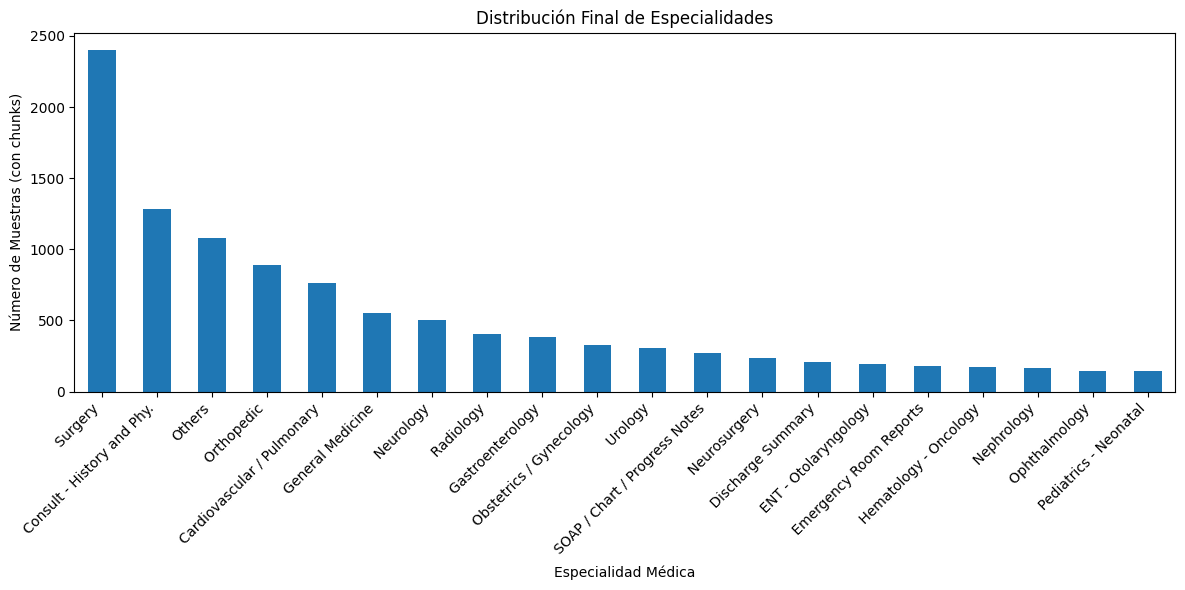

In [31]:
plt.figure(figsize=(12, 6))
df_processed['medical_specialty'].value_counts().plot(kind='bar')
plt.xlabel('Especialidad Médica')
plt.ylabel('Número de Muestras (con chunks)')
plt.title('Distribución Final de Especialidades')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

La distribución no ha cambiado significativamente después de hacer chunks.

In [36]:
# Guardamos el dataset procesado
df_processed.to_csv('../data/mtsamples_chunked.csv', index=False)